# 온라인 쇼핑몰 매출 관계분석
- 국가통계포털 https://kosis.kr/search/search.do
- 온라인쇼핑몰 판매매체별/상품군별거래액 검색
- 합계는 제외, 시점은 월별로 정리(단, 2020년도부터는 전기전자통신은 분리가됨)

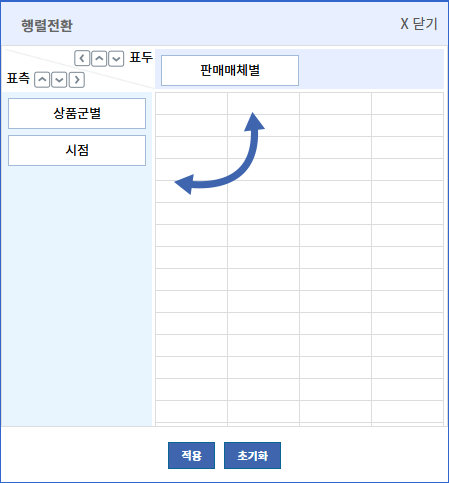

In [80]:
import pandas as pd
file_path = './dataset/온라인쇼핑몰판매매체별상품군별거래액202606.csv'
raw = pd.read_csv(file_path , encoding="EUC-KR")
raw.columns = ['category', 'year', 'internet', 'mobile']
raw

,category,year,internet,mobile
0,컴퓨터 및 주변기기,2020.01,332810,273459
1,컴퓨터 및 주변기기,2020.02,358997,315829
2,컴퓨터 및 주변기기,2020.03,401374,357883
3,컴퓨터 및 주변기기,2020.04,388215,331746
4,컴퓨터 및 주변기기,2020.05,323924,290304
...,...,...,...,...
1743,기타,2025.12,83267,181591
1744,기타,2026.01,69691,188568
1745,기타,2026.02,69460,168825
1746,기타,2026.03 p),86497,201182


In [2]:
#  p라는 문자를 제거하는 방법
# 방법1
# raw['year'] = raw['year'].str.replace(" p)","")
# 방법2
raw['year'] = raw['year'].str.rstrip(' p)')
# 방법3
# raw['year'] = raw['year'].map( lambda x : x.rstrip(' p)'))
raw

,category,year,internet,mobile
0,컴퓨터 및 주변기기,2020.01,332810,273459
1,컴퓨터 및 주변기기,2020.02,358997,315829
2,컴퓨터 및 주변기기,2020.03,401374,357883
3,컴퓨터 및 주변기기,2020.04,388215,331746
4,컴퓨터 및 주변기기,2020.05,323924,290304
...,...,...,...,...
1743,기타,2025.12,83267,181591
1744,기타,2026.01,69691,188568
1745,기타,2026.02,69460,168825
1746,기타,2026.03,86497,201182


In [3]:
raw['year'] = pd.to_datetime(raw['year'], format="%Y.%m")
raw["category"].unique()

array(['컴퓨터 및 주변기기', '가전·전자·통신기기', '서적', '사무·문구', '의복', '신발', '가방',
       '패션용품 및 액세서리', '스포츠·레저용품', '화장품', '아동·유아용품', '음·식료품', '농축수산물',
       '생활용품', '자동차 및 자동차용품', '가구', '애완용품', '여행 및 교통서비스', '문화 및 레저서비스',
       '이쿠폰서비스', '음식서비스', '기타서비스', '기타'], dtype=object)

In [23]:
mydata = raw.copy()
mydata2 = mydata[mydata["category"].isin(['컴퓨터 및 주변기기','자동차 및 자동차용품','서적','음식서비스','여행 및 교통서비스','문화 및 레저서비스','스포츠·레저용품'])]
mydata2.sample(10)

,category,year,internet,mobile
158,서적,2020-07-01,106713,86125
657,스포츠·레저용품,2024-02-01,99884,266671
1559,음식서비스,2023-04-01,37861,2512298
669,스포츠·레저용품,2025-02-01,106566,246893
1568,음식서비스,2024-01-01,35427,2895174
1551,음식서비스,2022-08-01,42626,2669025
636,스포츠·레저용품,2022-05-01,158580,425657
1126,자동차 및 자동차용품,2025-03-01,345736,179384
1382,문화 및 레저서비스,2021-03-01,28824,49044
1545,음식서비스,2022-02-01,49522,2648228


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

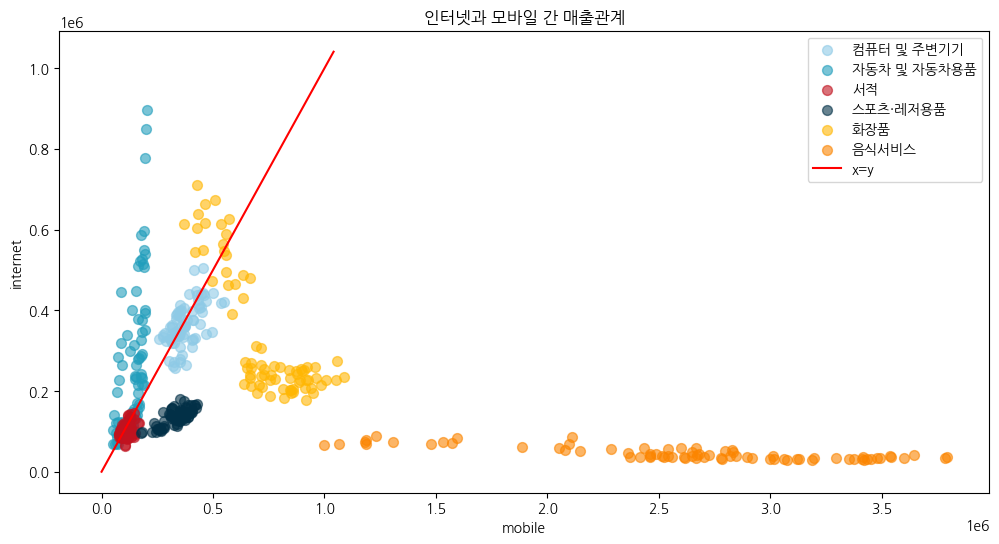

In [79]:
import matplotlib.pyplot as plt
import numpy as np

category = ['컴퓨터 및 주변기기','자동차 및 자동차용품','서적','스포츠·레저용품','화장품','음식서비스']
colors = {'컴퓨터 및 주변기기':'#8ecae6',
          '자동차 및 자동차용품':'#219ebc',
          '서적':"#c1121f",
          '스포츠·레저용품':'#023047',
          '화장품':'#ffb703',
          '음식서비스':'#fb8500'}

# 색상반환함수
def color_by(category_name):
    return colors.get(category_name,'black') # 기본값은 블랙


fig , ax = plt.subplots(figsize=(12,6))
for c in category:
    prod = mydata[ mydata["category"]== c]
    x = prod['mobile']
    y = prod['internet']
    ax.scatter(x,y, s=50, color= color_by(c), label=c, alpha=0.6)

xx = np.linspace(0 , max(mydata2['internet']), 1000)
plt.plot(xx, xx, color='red', linestyle='-', label='x=y')

ax.set_title('인터넷과 모바일 간 매출관계')
ax.set_xlabel('mobile')
ax.set_ylabel('internet')
ax.legend()
plt.show()